<a href="https://colab.research.google.com/github/Fares-pr0g/ML-journey-ep-2-Experimenting-with-NN-s-in-PyTorch/blob/main/Learning_PyTorch02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Making a toy dataset (two concentric differently coloured circles)

from sklearn.datasets import make_circles
X_np,y_np= make_circles(n_samples= 1000, noise=0.03, random_state=42)

In [2]:
# Let's make a DataFrame for the data

import pandas as pd
circles= pd.DataFrame({"X1": X_np[:,0], "X2": X_np[:,1], "label": y_np})
circles.head(10)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


In [3]:
print(circles.label.value_counts())
# we have balanced data, cool!

label
1    500
0    500
Name: count, dtype: int64


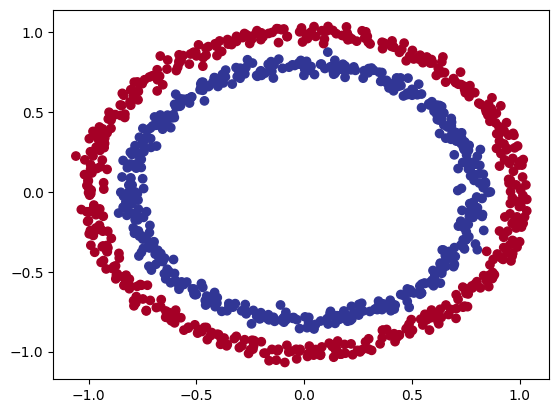

In [4]:
# Let's vizualise the data first

import matplotlib.pyplot as plt
plt.scatter(x=X_np[:,0], y=X_np[:,1], c=y_np, cmap= plt.cm.RdYlBu)

In [5]:
# Let's split the data to train & test
#first we need to turn data into tensors (for pytorch)

import torch
X= torch.from_numpy(X_np).type(torch.float)
y= torch.from_numpy(y_np).type(torch.float)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test= train_test_split(X,y,
                                                   test_size=0.2,
                                                   random_state=42)


In [6]:
device= 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

In [7]:
# Building a linear model (weak for our problem)
from torch import nn

class CircleModelV0(nn.Module):
  def __init__(self):
    super().__init__()

    self.layer_1= nn.Linear(in_features=2, out_features=5)
    self.layer_2= nn.Linear(in_features=5, out_features=1)

  def forward(self,X):
    return self.layer_2(self.layer_1(X))

torch.manual_seed(42)
model_0= CircleModelV0().to(device)
model_0

CircleModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [8]:
# let's set the training components

optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.1)
loss_fn= nn.BCEWithLogitsLoss()

def accuracy(y_true,y_pred):
  corrects= torch.eq(y_true,y_pred).sum().item()
  return (corrects/len(y_true))*100

In [9]:
# Let's set a training loop
torch.manual_seed(42)
epochs= 100

# Let's put the data to target device first
X_train, X_test= X_train.to(device), X_test.to(device)
y_train, y_test= y_train.to(device), y_test.to(device)

for epoch in range(epochs):

  model_0.train()
  y_logits= model_0(X_train).squeeze()
  y_pred= torch.round(torch.sigmoid(y_logits))
  train_loss= loss_fn(y_logits, y_train)
  train_acc= accuracy(y_train, y_pred)

  optimizer.zero_grad()
  train_loss.backward()
  optimizer.step()

  model_0.eval()
  with torch.inference_mode():
    test_logits= model_0(X_test).squeeze()
    test_pred= torch .round(torch.sigmoid(test_logits))
    test_loss= loss_fn(test_logits, y_test)
    test_acc= accuracy(y_test, test_pred)

    if epoch %10 ==0:
      print(f"Epoch: {epoch} | Train Loss: {train_loss:.5f} | Train Acc: {train_acc:.2f}% | Test Loss: {test_loss:.5f} | Test Acc: {test_acc:.2f}%")

Epoch: 0 | Train Loss: 0.69569 | Train Acc: 50.00% | Test Loss: 0.69721 | Test Acc: 50.00%
Epoch: 10 | Train Loss: 0.69403 | Train Acc: 50.00% | Test Loss: 0.69615 | Test Acc: 50.00%
Epoch: 20 | Train Loss: 0.69343 | Train Acc: 46.00% | Test Loss: 0.69585 | Test Acc: 48.50%
Epoch: 30 | Train Loss: 0.69321 | Train Acc: 49.00% | Test Loss: 0.69577 | Test Acc: 47.50%
Epoch: 40 | Train Loss: 0.69312 | Train Acc: 49.50% | Test Loss: 0.69573 | Test Acc: 46.50%
Epoch: 50 | Train Loss: 0.69308 | Train Acc: 50.38% | Test Loss: 0.69569 | Test Acc: 46.50%
Epoch: 60 | Train Loss: 0.69306 | Train Acc: 50.50% | Test Loss: 0.69564 | Test Acc: 46.50%
Epoch: 70 | Train Loss: 0.69305 | Train Acc: 50.50% | Test Loss: 0.69559 | Test Acc: 46.50%
Epoch: 80 | Train Loss: 0.69304 | Train Acc: 50.75% | Test Loss: 0.69553 | Test Acc: 46.50%
Epoch: 90 | Train Loss: 0.69303 | Train Acc: 50.38% | Test Loss: 0.69547 | Test Acc: 46.50%


In [10]:
import requests
from pathlib import Path

# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

helper_functions.py already exists, skipping download


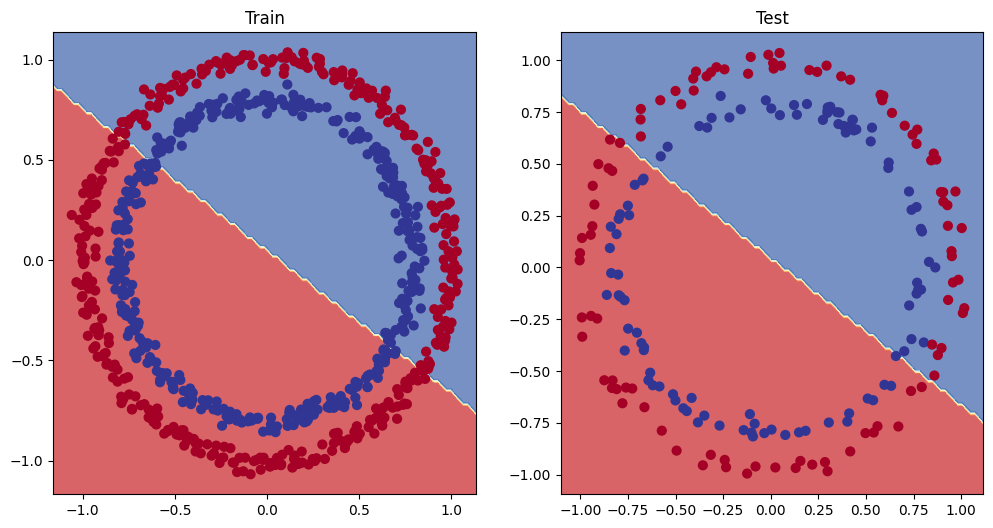

In [11]:
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_0, X_test, y_test)

In [12]:
# building a better model (adding activation functions + expanding the NN overall)

class CircleModelV1(nn.Module):

  def __init__(self):
    super().__init__()
    self.layer_1= nn.Linear(in_features= 2, out_features=10)
    self.layer_2= nn.Linear(in_features= 10, out_features=10)
    self.layer_3= nn.Linear(in_features= 10, out_features=1)
    self.relu =nn.ReLU()

  def forward(self, X):
    X= self.layer_1(X)
    X= self.relu(X)
    X= self.layer_2(X)
    X= self.relu(X)
    X= self.layer_3(X)
    return X

torch.manual_seed(42)
Model_1=CircleModelV1().to(device)
Model_1

CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [13]:
# we need a new loss_fn & optimizer
loss_fn= nn.BCEWithLogitsLoss()
optimizer_1= torch.optim.SGD(params=Model_1.parameters(), lr=0.1)

In [14]:
y_pred= Model_1(X_test).squeeze()
y_pred.shape, y_test.shape

(torch.Size([200]), torch.Size([200]))

In [15]:
# Fitting the model
torch.manual_seed(42)
epochs= 1000

#this step is already done previously, but for clarity we'll have it again
X_train, X_test= X_train.to(device), X_test.to(device)
y_train, y_test= y_train.to(device), y_test.to(device)

for epoch in range(epochs):

  Model_1.train()
  y_logits=Model_1(X_train).squeeze()
  y_pred= torch.round(torch.sigmoid(y_logits))
  train_loss= loss_fn(y_logits, y_train)
  train_acc= accuracy(y_true=y_train, y_pred=y_pred)

  optimizer_1.zero_grad()
  train_loss.backward()
  optimizer_1.step()

  Model_1.eval()
  with torch.inference_mode():
    test_logits= Model_1(X_test).squeeze()
    test_pred= torch.round(torch.sigmoid(test_logits))
    test_loss= loss_fn(test_logits, y_test)
    test_acc= accuracy(y_true=y_test, y_pred=test_pred)

    if epoch %100 ==0:
      print(f"Epoch: {epoch} | Train Loss: {train_loss:.5f} | Train Acc: {train_acc:.2f}% | Test Loss: {test_loss:.5f} | Test Acc: {test_acc:.2f}")

Epoch: 0 | Train Loss: 0.69295 | Train Acc: 50.00% | Test Loss: 0.69319 | Test Acc: 50.00
Epoch: 100 | Train Loss: 0.69115 | Train Acc: 52.88% | Test Loss: 0.69102 | Test Acc: 52.50
Epoch: 200 | Train Loss: 0.68977 | Train Acc: 53.37% | Test Loss: 0.68940 | Test Acc: 55.00
Epoch: 300 | Train Loss: 0.68795 | Train Acc: 53.00% | Test Loss: 0.68723 | Test Acc: 56.00
Epoch: 400 | Train Loss: 0.68517 | Train Acc: 52.75% | Test Loss: 0.68411 | Test Acc: 56.50
Epoch: 500 | Train Loss: 0.68102 | Train Acc: 52.75% | Test Loss: 0.67941 | Test Acc: 56.50
Epoch: 600 | Train Loss: 0.67515 | Train Acc: 54.50% | Test Loss: 0.67285 | Test Acc: 56.00
Epoch: 700 | Train Loss: 0.66659 | Train Acc: 58.38% | Test Loss: 0.66322 | Test Acc: 59.00
Epoch: 800 | Train Loss: 0.65160 | Train Acc: 64.00% | Test Loss: 0.64757 | Test Acc: 67.50
Epoch: 900 | Train Loss: 0.62362 | Train Acc: 74.00% | Test Loss: 0.62145 | Test Acc: 79.00


In [16]:
# Let's test the model and make predictions
Model_1.eval()
with torch.inference_mode():
  test_pred= torch.round(torch.sigmoid(Model_1(X_test).squeeze()))
  acc= accuracy(y_true=y_test, y_pred=test_pred)
  print(f"Model 1 test accuracy: {acc:.2f}%")
Comparison=pd.DataFrame({"y_test": y_test.cpu(), "y_pred": test_pred.cpu()})
Comparison


Model 1 test accuracy: 86.50%


,y_test,y_pred
0,1.0,1.0
1,0.0,0.0
2,1.0,1.0
3,0.0,0.0
4,1.0,0.0
...,...,...
195,0.0,0.0
196,1.0,0.0
197,0.0,0.0
198,1.0,0.0


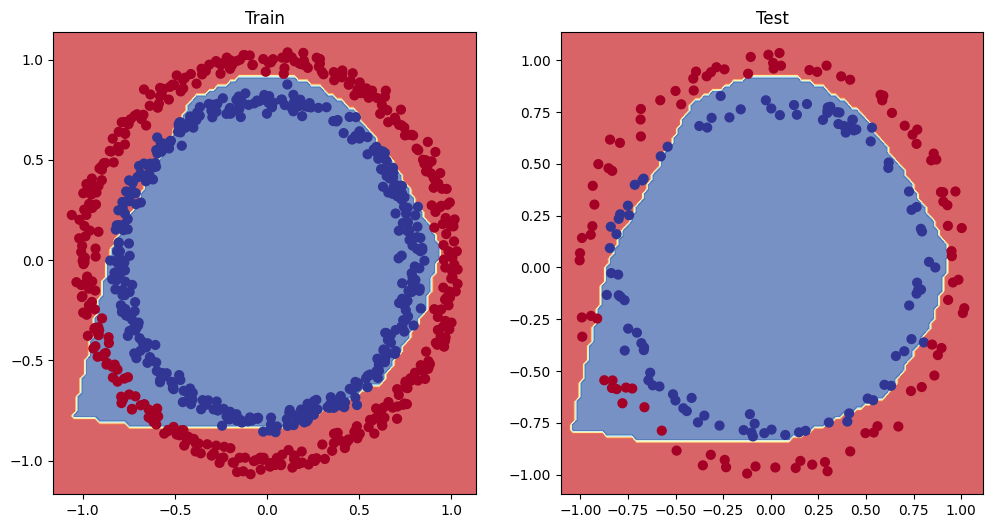

In [17]:
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(Model_1, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(Model_1, X_test, y_test)

**-> It's clear that the non-linear is fitting better to the circular data**

### WHAT if we use the tanh activation function instead of ReLu?

In [18]:

class CircleModelV2(nn.Module):

  def __init__(self):
    super().__init__()
    self.layer_1= nn.Linear(in_features= 2, out_features=10)
    self.layer_2= nn.Linear(in_features= 10, out_features=10)
    self.layer_3= nn.Linear(in_features= 10, out_features=1)
    self.tanh =nn.Tanh()

  def forward(self, X):
    X= self.layer_1(X)
    X= self.tanh(X)
    X= self.layer_2(X)
    X= self.tanh(X)
    X= self.layer_3(X)
    return X

torch.manual_seed(42)
Model_2=CircleModelV1().to(device)
Model_2

CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [19]:
# we need a new loss_fn & optimizer
loss_fn= nn.BCEWithLogitsLoss()
optimizer_2= torch.optim.SGD(params=Model_2.parameters(), lr=0.1)

In [20]:
# Fitting the model
torch.manual_seed(42)
epochs= 2000

#this step is already done previously, but for clarity we'll have it again
X_train, X_test= X_train.to(device), X_test.to(device)
y_train, y_test= y_train.to(device), y_test.to(device)

for epoch in range(epochs):

  Model_2.train()
  y_logits=Model_2(X_train).squeeze()
  y_pred= torch.round(torch.sigmoid(y_logits))
  train_loss= loss_fn(y_logits, y_train)
  train_acc= accuracy(y_true=y_train, y_pred=y_pred)

  optimizer_2.zero_grad()
  train_loss.backward()
  optimizer_2.step()

  Model_2.eval()
  with torch.inference_mode():
    test_logits= Model_2(X_test).squeeze()
    test_pred= torch.round(torch.sigmoid(test_logits))
    test_loss= loss_fn(test_logits, y_test)
    test_acc= accuracy(y_true=y_test, y_pred=test_pred)

    if epoch %100 ==0:
      print(f"Epoch: {epoch} | Train Loss: {train_loss:.5f} | Train Acc: {train_acc:.2f}% | Test Loss: {test_loss:.5f} | Test Acc: {test_acc:.2f}")

Epoch: 0 | Train Loss: 0.69295 | Train Acc: 50.00% | Test Loss: 0.69319 | Test Acc: 50.00
Epoch: 100 | Train Loss: 0.69115 | Train Acc: 52.88% | Test Loss: 0.69102 | Test Acc: 52.50
Epoch: 200 | Train Loss: 0.68977 | Train Acc: 53.37% | Test Loss: 0.68940 | Test Acc: 55.00
Epoch: 300 | Train Loss: 0.68795 | Train Acc: 53.00% | Test Loss: 0.68723 | Test Acc: 56.00
Epoch: 400 | Train Loss: 0.68517 | Train Acc: 52.75% | Test Loss: 0.68411 | Test Acc: 56.50
Epoch: 500 | Train Loss: 0.68102 | Train Acc: 52.75% | Test Loss: 0.67941 | Test Acc: 56.50
Epoch: 600 | Train Loss: 0.67515 | Train Acc: 54.50% | Test Loss: 0.67285 | Test Acc: 56.00
Epoch: 700 | Train Loss: 0.66659 | Train Acc: 58.38% | Test Loss: 0.66322 | Test Acc: 59.00
Epoch: 800 | Train Loss: 0.65160 | Train Acc: 64.00% | Test Loss: 0.64757 | Test Acc: 67.50
Epoch: 900 | Train Loss: 0.62362 | Train Acc: 74.00% | Test Loss: 0.62145 | Test Acc: 79.00
Epoch: 1000 | Train Loss: 0.56818 | Train Acc: 87.75% | Test Loss: 0.57378 | Test 

In [21]:
# Let's test the model and make predictions
Model_2.eval()
with torch.inference_mode():
  test_pred= torch.round(torch.sigmoid(Model_2(X_test).squeeze()))
  acc= accuracy(y_true=y_test, y_pred=test_pred)
  print(f"Model 2 test accuracy: {acc:.2f}%")

Model 2 test accuracy: 100.00%


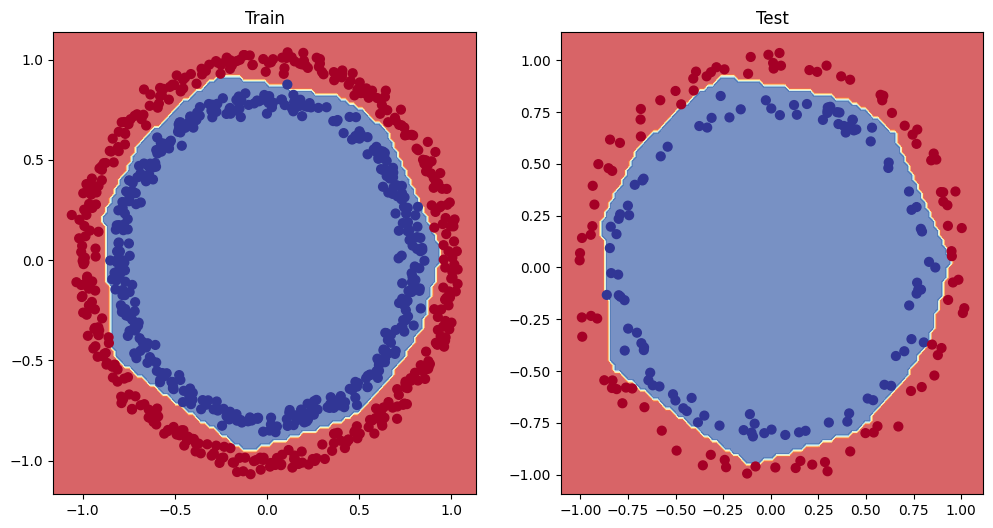

In [22]:
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(Model_2, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(Model_2, X_test, y_test)

**--> In reality the activation function itself didn't make a difference, however the number of epochs did (quite a big one!)**

# Now let's work with multi-class classification data

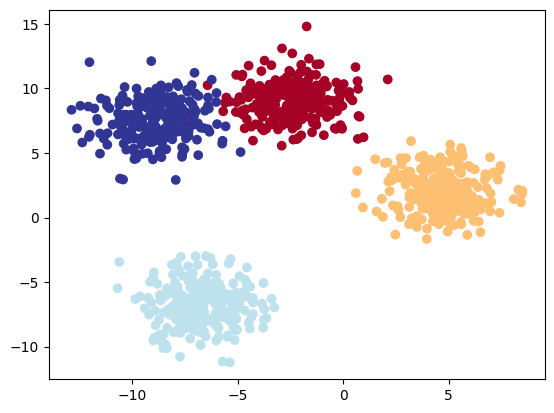

In [23]:
import torch
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_blobs

# Let's create a multi-class toy dataset
X_blob,y_blob= make_blobs(
    n_samples= 1000,
    centers= 4,
    n_features= 2, #nb of dimensions in the n-dimension space
    cluster_std=1.5,
    random_state= 42
)

X_blob= torch.from_numpy(X_blob).type(torch.float)
y_blob= torch.from_numpy(y_blob).type(torch.LongTensor)

# Spliting the data
X_blob_train, X_blob_test, y_blob_train, y_blob_test= train_test_split(X_blob,y_blob,
                                                   test_size=0.2,
                                                   random_state=42)
# Ploting the data
plt.scatter(X_blob[:,0], X_blob[:,1], c=y_blob, cmap=plt.cm.RdYlBu)


In [24]:
# Let's build a multi-class classification model
from torch import nn

class BlobModel(nn.Module):

  def __init__(self, input_features, output_features, hidden_units=8):
    super().__init__()

    self.linear_stack= nn.Sequential(
        nn.Linear(in_features=input_features, out_features=hidden_units),
        nn.Linear(in_features=hidden_units, out_features=hidden_units),
        nn.Linear(in_features=hidden_units, out_features=output_features)
    )

  def forward(self, X):
    return self.linear_stack(X)

torch.manual_seed(42)
Model_4= BlobModel(input_features=2,
                   output_features=4,
                   hidden_units=8)
Model_4

BlobModel(
  (linear_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): Linear(in_features=8, out_features=8, bias=True)
    (2): Linear(in_features=8, out_features=4, bias=True)
  )
)

In [25]:
# loss funct & optimizer
loss_fn= nn.CrossEntropyLoss()
optimizer_4= torch.optim.SGD(params=Model_4.parameters(), lr=0.1)

In [26]:
# Fit the model
torch.manual_seed(42)

# Set number of epochs
epochs = 100

# Put data to target device
X_blob_train, y_blob_train = X_blob_train.to(device), y_blob_train.to(device)
X_blob_test, y_blob_test = X_blob_test.to(device), y_blob_test.to(device)

for epoch in range(epochs):
    ### Training
    Model_4.train()

    # 1. Forward pass
    y_logits = Model_4(X_blob_train) # model outputs raw logits
    y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1) # go from logits -> prediction probabilities -> prediction labels
    # print(y_logits)
    # 2. Calculate loss and accuracy
    loss = loss_fn(y_logits, y_blob_train)
    acc = accuracy(y_true=y_blob_train,
                      y_pred=y_pred)

    # 3. Optimizer zero grad
    optimizer_4.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Optimizer step
    optimizer_4.step()

    ### Testing
    Model_4.eval()
    with torch.inference_mode():
      # 1. Forward pass
      test_logits = Model_4(X_blob_test)
      test_pred = torch.softmax(test_logits, dim=1).argmax(dim=1)
      # 2. Calculate test loss and accuracy
      test_loss = loss_fn(test_logits, y_blob_test)
      test_acc = accuracy(y_true=y_blob_test,
                             y_pred=test_pred)

    # Print out what's happening
    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Acc: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test Acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 1.04324, Acc: 65.50% | Test Loss: 0.57861, Test Acc: 95.50%
Epoch: 10 | Loss: 0.14398, Acc: 99.12% | Test Loss: 0.13037, Test Acc: 99.00%
Epoch: 20 | Loss: 0.08062, Acc: 99.12% | Test Loss: 0.07216, Test Acc: 99.50%
Epoch: 30 | Loss: 0.05924, Acc: 99.12% | Test Loss: 0.05133, Test Acc: 99.50%
Epoch: 40 | Loss: 0.04892, Acc: 99.00% | Test Loss: 0.04098, Test Acc: 99.50%
Epoch: 50 | Loss: 0.04295, Acc: 99.00% | Test Loss: 0.03486, Test Acc: 99.50%
Epoch: 60 | Loss: 0.03910, Acc: 99.00% | Test Loss: 0.03083, Test Acc: 99.50%
Epoch: 70 | Loss: 0.03643, Acc: 99.00% | Test Loss: 0.02799, Test Acc: 99.50%
Epoch: 80 | Loss: 0.03448, Acc: 99.00% | Test Loss: 0.02587, Test Acc: 99.50%
Epoch: 90 | Loss: 0.03300, Acc: 99.12% | Test Loss: 0.02423, Test Acc: 99.50%


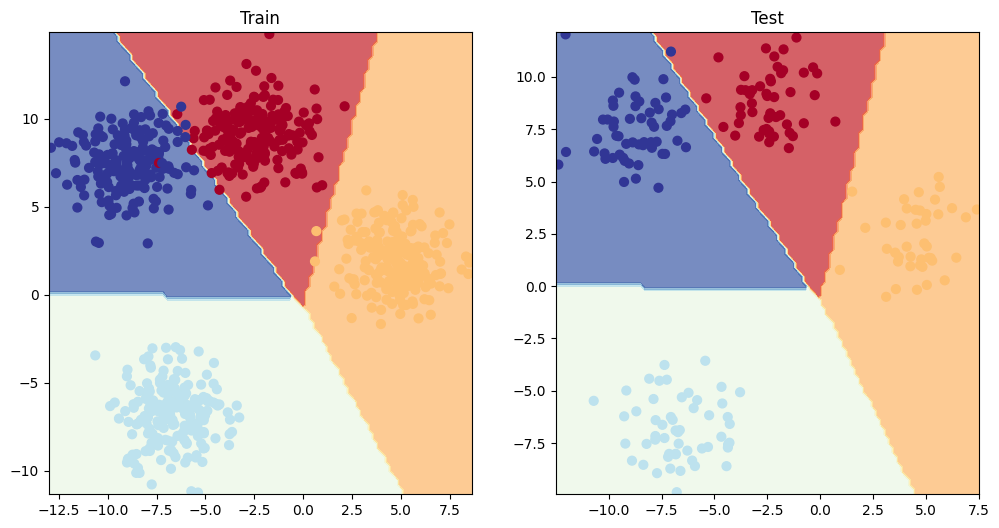

In [28]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(Model_4, X_blob_train, y_blob_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(Model_4, X_blob_test, y_blob_test)